# TauRex3 gradients: from limitation to autograd

This notebook follows a narrow story:

1. Build a realistic TauRex transmission problem with H2O absorption, CIA, and Rayleigh scattering.
2. Show why the current TauRex forward model cannot provide gradients to PyTorch autograd.
3. Reimplement the same physics in PyTorch and check that the spectrum matches TauRex numerically.
4. Compare the cost of the forward pass and the gradient.
5. Inspect the gradients explicitly through scalar derivatives and spectral sensitivities.

> Data: the notebook downloads the TauRex starter dataset automatically if it is not already present.

## 0. Imports

In [1]:
import inspect
import math

import numpy as np
import matplotlib.pyplot as plt
import torch

from taurex.cache import OpacityCache, CIACache
import taurex.log
taurex.log.disableLogging()

print(f"NumPy  {np.__version__}")
print(f"PyTorch {torch.__version__}")


NumPy  2.4.3
PyTorch 2.10.0+cu128


### 0a. Download starter data

This downloads the TauRex starter dataset, extracts it once, and then auto-detects the opacity and CIA directories. Re-running the cell is safe.

In [2]:
import urllib.request
import zipfile
import os
from pathlib import Path

DATA_DIR = Path("taurex_starter_data")
ZIP_FILE = Path("taurex_starter.zip")

if not DATA_DIR.exists():
    print("Downloading starter data ...")
    url = "https://www.dropbox.com/sh/13y33d02vh56jh2/AABxuHdrZI83bSgoLz1Wzb2Fa?dl=1"
    urllib.request.urlretrieve(url, ZIP_FILE)
    print("Extracting ...")
    with zipfile.ZipFile(ZIP_FILE, "r") as z:
        z.extractall(DATA_DIR)
    ZIP_FILE.unlink()
    print("Done!")
else:
    print("Data directory already exists — skipping download.")

# Auto-detect xsec and CIA directories.
#
# xsec: look for .pickle / .hdf5 / .h5 files only (not .db) inside xsec/.
#   - xsec/R7000 contains .db files not handled by built-in PickleOpacity/HDF5Opacity.
#   - xsec/xsec_sampled_R15000_* contain .pickle files readable by PickleOpacity.
#   - ktables/ is tried as a fallback after xsec/.
#
# cia: search only inside cia/ to avoid confusing xsec .db files with CIA .db files.
xsec_extensions = {".hdf5", ".h5", ".pickle"}   # .db excluded: no built-in reader
cia_extensions  = {".cia", ".db"}

xsec_path = cia_path = None

# xsec: search xsec/ first, then ktables/ as fallback
for xsec_subdir in [DATA_DIR / "xsec", DATA_DIR / "ktables"]:
    if xsec_subdir.exists():
        for dirpath, dirnames, filenames in os.walk(xsec_subdir):
            dirnames.sort()
            exts = {Path(f).suffix.lower() for f in filenames}
            if exts & xsec_extensions and xsec_path is None:
                xsec_path = dirpath
    if xsec_path:
        break

# cia: search only inside the cia/ subdirectory
cia_subdir = DATA_DIR / "cia"
if cia_subdir.exists():
    for dirpath, dirnames, filenames in os.walk(cia_subdir):
        dirnames.sort()
        exts = {Path(f).suffix.lower() for f in filenames}
        if exts & cia_extensions and cia_path is None:
            cia_path = dirpath

print(f"xsec_path : {xsec_path}")
print(f"cia_path  : {cia_path}")


Data directory already exists — skipping download.
xsec_path : taurex_starter_data/xsec/xsec_sampled_R15000_0.3-15
cia_path  : taurex_starter_data/cia/Borysow


In [3]:
# Load opacity and CIA tables into the TauRex caches
OpacityCache().clear_cache()
OpacityCache().set_opacity_path(xsec_path)
CIACache().set_cia_path(cia_path)

h2o_xsec = OpacityCache()["H2O"]
cia_h2h2  = CIACache()["H2-H2"]
cia_h2he  = CIACache()["H2-He"]

print(f"H2O xsec  :  T = {h2o_xsec.temperatureGrid.min():.0f}–"
      f"{h2o_xsec.temperatureGrid.max():.0f} K  |  "
      f"wn = {h2o_xsec.wavenumberGrid.min():.0f}–"
      f"{h2o_xsec.wavenumberGrid.max():.0f} cm⁻¹  |  "
      f"grid shape = {h2o_xsec.xsecGrid.shape}")
print(f"CIA H2-H2 :  T = {cia_h2h2.temperatureGrid.min():.0f}–"
      f"{cia_h2h2.temperatureGrid.max():.0f} K")
print(f"CIA H2-He :  T = {cia_h2he.temperatureGrid.min():.0f}–"
      f"{cia_h2he.temperatureGrid.max():.0f} K")


/home/simone/Dropbox/eScience_projects/TauRex/taurex3/src/taurex/opacity/pickleopacity.py:108: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  self._spec_dict = pickle.load(f)  # noqa


H2O xsec  :  T = 100–3400 K  |  wn = 667–33333 cm⁻¹  |  grid shape = (22, 27, 58684)
CIA H2-H2 :  T = 400–7000 K
CIA H2-He :  T = 400–7000 K


/home/simone/Dropbox/eScience_projects/TauRex/taurex3/src/taurex/cia/picklecia.py:56: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  self._spec_dict = pickle.load(f, encoding="latin1")  # noqa: S301


---
## 1. Build a TauRex reference problem

We use a compact but realistic transmission setup: an isothermal atmosphere, H2O absorption from the TauRex tables, H2-H2 and H2-He CIA, and H2 Rayleigh scattering.

This gives us a reference TauRex spectrum to match before asking anything about gradients.

In [4]:
from taurex.temperature import Isothermal
from taurex.planet import Planet
from taurex.stellar import BlackbodyStar
from taurex.chemistry import TaurexChemistry, ConstantGas
from taurex.model import TransmissionModel
from taurex.contributions import RayleighContribution, AbsorptionContribution
from taurex.contributions import CIAContribution

planet    = Planet(planet_radius=1.0, planet_mass=1.0)
star      = BlackbodyStar(temperature=5700.0, radius=1.0)
temp      = Isothermal(T=1500.0)
chemistry = TaurexChemistry(fill_gases=["H2", "He"], ratio=0.172)
chemistry.addGas(ConstantGas("H2O", mix_ratio=1e-4))

tm = TransmissionModel(
    planet=planet,
    star=star,
    temperature_profile=temp,
    chemistry=chemistry,
    atm_min_pressure=1e-1,
    atm_max_pressure=1e6,
    nlayers=30,
)
tm.add_contribution(AbsorptionContribution())
tm.add_contribution(CIAContribution(cia_pairs=["H2-H2", "H2-He"]))
tm.add_contribution(RayleighContribution())
tm.build()
print("Model built  (H2O absorption + CIA H2-H2/H2-He + Rayleigh).")


Model built  (H2O absorption + CIA H2-H2/H2-He + Rayleigh).


In [5]:
# With real opacity data loaded, tm.model() can now run directly.
# We choose a wavenumber grid covering the main H2O absorption bands (1–5 µm).
wngrid = np.linspace(2000.0, 9500.0, 500)   # cm⁻¹

# tm.model() returns: (native_wngrid, transit_depth, optical_depth_array, None)
wngrid, spectrum, tau_ref, _ = tm.model(wngrid)

print(f"Spectrum shape : {spectrum.shape}")
print(f"Type           : {type(spectrum)}")
print(f"min / max      : {spectrum.min():.4e}  /  {spectrum.max():.4e}")


Spectrum shape : (23510,)
Type           : <class 'numpy.ndarray'>
min / max      : 1.0750e-02  /  1.1635e-02


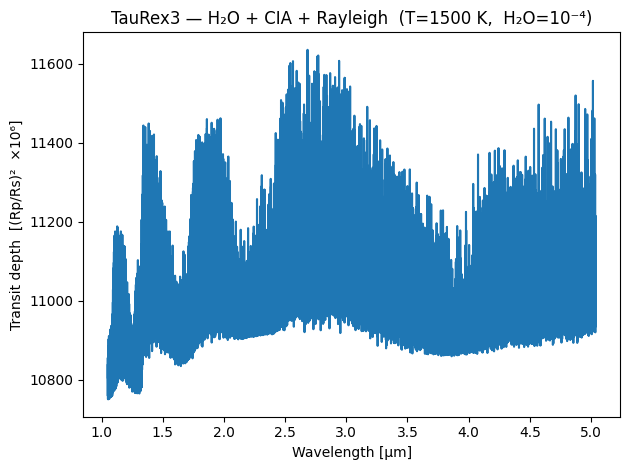

In [6]:
fig, ax = plt.subplots()
ax.plot(10000.0 / wngrid, spectrum * 1e6)
ax.set_xlabel("Wavelength [µm]")
ax.set_ylabel("Transit depth  [(Rp/Rs)²  ×10⁶]")
ax.set_title("TauRex3 — H₂O + CIA + Rayleigh  (T=1500 K,  H₂O=10⁻⁴)")
plt.tight_layout()
plt.show()


---
## 2. Why TauRex cannot give us gradients today

A gradient-based sampler needs derivatives of the model output with respect to the atmospheric parameters. Simply converting the final NumPy spectrum to a torch tensor does not help, because PyTorch only differentiates operations that were executed inside its own computation graph.

The next cells show that failure directly, then point to the main structural reasons in the TauRex implementation.

In [7]:
T_param = torch.tensor(1500.0, requires_grad=True)

# tm.model() runs TauRex's full NumPy pipeline — H2O cross-section table lookup,
# bilinear interpolation, CIA integration, Rayleigh scattering, path integrals.
# PyTorch never observes any of that computation, so the resulting tensor is detached.
_, spec_np, _, _ = tm.model(wngrid)          # pure NumPy array from TauRex
spec_torch = torch.tensor(spec_np)           # copy into torch — grad_fn is None!

print(f"spec_torch.requires_grad : {spec_torch.requires_grad}")
print(f"spec_torch.grad_fn       : {spec_torch.grad_fn}")

try:
    grad = torch.autograd.grad(spec_torch.sum(), T_param)
    print("Gradient:", grad)
except RuntimeError as exc:
    print(f"RuntimeError: {exc}")


spec_torch.requires_grad : False
spec_torch.grad_fn       : None
RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn


### 2a. The main blockers in the current implementation

The two most visible blockers are:

- In-place accumulation inside the optical-depth build-up.
- Value-dependent control flow in the path integral.

Those are enough to break a straightforward autograd path, and they sit on top of two broader engineering constraints: the hot loop is also wrapped in Numba, and the model is exposed through mutable object state rather than a pure tensor function.

In [8]:
# ── Blocker 1: in-place mutation  ──────────────────────────────────────────────────────────────
# torch.autograd (and JAX) cannot differentiate through in-place operations.
from taurex.contributions.contribution import contribute_tau_numpy
src = inspect.getsource(contribute_tau_numpy)
# Print only the executable body
for line in src.splitlines():
    if not line.strip().startswith('"""') and '"""' not in line:
        print(line)

def contribute_tau_numpy(
    startk: int,
    endk: int,
    density_offset: int,
    sigma: npt.NDArray[np.float64],
    density: npt.NDArray[np.float64],
    path: npt.NDArray[np.float64],
    nlayers: int,
    ngrid: int,
    layer: int,
    tau: npt.NDArray[np.float64],
) -> npt.NDArray[np.float64]:

    This has the form:

    .. math::

        \\tau_{\\lambda}(z) = \\int_{z_{0}}^{z_{1}} \\sigma(z') \\rho(z') dz',

    where :math:`z` is the layer, :math:`z_0` and :math:`z_1` are ``startK``
    and ``endK`` respectively. :math:`\\sigma` is the weighted
    cross-section ``sigma``. :math:`rho` is the ``density`` and
    :math:`dz'` is the integration path length ``path``


    Parameters
    ----------
    startK: int
        starting layer in integration

    endK: int
        last layer in integration

    density_offset: int
        Which part of the density profile to start from

    sigma: :obj:`array`
        cross-section

    density: array_like
        density profile of

In [9]:
# ── Blocker 2: data-dependent control flow  ────────────────────────────────────────────────────
# `if tau[layer].min() > 10` branches on a tensor value — PyTorch can't trace through this.
from taurex.model.transmission import TransmissionModel as _TM
for line in inspect.getsource(_TM.path_integral).splitlines():
    stripped = line.strip()
    if any(kw in stripped for kw in ('for layer', 'if tau', 'contribute(', 'tau = np.zeros')):
        print(line)

        tau = np.zeros(shape=(total_layers, wngrid_size), dtype=np.float64)
        for layer in range(total_layers):
                if tau[layer].min() > 10:
                contrib.contribute(


In practice the rewrite in this notebook looks like this:

| TauRex | Quick PyTorch fix |
|---|---|
| In-place accumulation inside kernels: `tau[layer, :] += ...` | Build the full tensor expression explicitly: `sigma_rho = ...`; `tau_chord = dl @ sigma_rho` |
| Value-dependent control flow: `if tau[layer].min() > 10: break` | Keep one fixed program: no value-triggered `break`, same tensor graph every call |
| Loop-style optical-depth update, e.g. `tau[layer, wn] += sigma[k + layer, wn] * _path * _density` | Replace the inner accumulation with tensor algebra: `sigma_rho = sigma * rho[:, None]`; `tau_chord = dl @ sigma_rho` |
| Numba-compiled kernels: `contribute_tau(...)`, `contribute_cia(...)` | No Numba |
| Stateful model call: `tm.model(wngrid)` | Explicit differentiable function: `depth = transmission_torch(T, log10_H2O_mix, c=cache)` |

Same physics, different implementation: the PyTorch version turns the transmission model into an explicit parameter-to-spectrum tensor function, so gradients can be obtained directly from autograd.

---
## 3. Rebuild the same model in PyTorch

The goal is not to change the physics. The goal is to express the same calculation in tensor operations that PyTorch can differentiate.

The cached object below only stores quantities that do not change between calls, such as the pressure grid and opacity tables interpolated onto the working wavenumber grid. The actual forward function then depends only on the parameters we want to vary.

In [10]:
import math
from dataclasses import dataclass

KB = 1.380649e-23   # J/K
AMAGAT_NUMBER_DENSITY = 2.6867805e25
CIA_CGS_TO_SI = 100.0 / AMAGAT_NUMBER_DENSITY**2

def _rayleigh_h2_m2(wngrid: torch.Tensor) -> torch.Tensor:
    wave = 1e8 / wngrid   # cm⁻¹ → Angstroms
    return 8.14e-13 * wave**-4 * (1.0 + 1.572e6 * wave**-2 + 1.981e12 * wave**-4) * 1e-4

@dataclass
class ModelCache:
    """Quantities pre-computed once and shared across all forward-model calls."""
    wngrid_t: torch.Tensor
    pressure_levels: torch.Tensor
    pressure_layers: torch.Tensor
    log_pressure_step: torch.Tensor
    Rp: torch.Tensor
    Rs: torch.Tensor
    planet_mass: torch.Tensor
    mu_mol: torch.Tensor
    nlayers: int
    sigma_ray: torch.Tensor
    h2o_xsec: torch.Tensor
    h2o_T_grid: torch.Tensor
    h2o_logP_grid: torch.Tensor
    h2o_iP0: torch.Tensor
    h2o_iP1: torch.Tensor
    h2o_wP: torch.Tensor
    cia_h2h2: torch.Tensor
    cia_h2h2_T: torch.Tensor
    cia_h2he: torch.Tensor
    cia_h2he_T: torch.Tensor
    H2_mix: float
    He_mix: float

def _interp_cia_table_to_wngrid(cia_obj, wngrid_np):
    nT = len(cia_obj.temperatureGrid)
    out = np.zeros((nT, len(wngrid_np)))
    for it in range(nT):
        out[it] = np.interp(
            wngrid_np, cia_obj.wavenumberGrid, cia_obj._xsec_grid[it], left=0.0, right=0.0
        )
    return cia_obj.temperatureGrid.copy(), out

def build_model_cache(
    model, wngrid_np, xsec_h2o, cia_h2h2_obj, cia_h2he_obj,
    H2_mix=0.85, He_mix=0.172 * 0.85,
) -> ModelCache:
    wngrid_t = torch.tensor(np.array(wngrid_np, copy=True), dtype=torch.float64)
    pressure_levels = torch.tensor(np.array(model.pressure.pressure_profile_levels, copy=True), dtype=torch.float64)
    pressure_layers = torch.tensor(np.array(model.pressureProfile, copy=True), dtype=torch.float64)
    log_pressure_step = torch.log(pressure_levels[:-1] / pressure_levels[1:])

    raw = xsec_h2o.xsecGrid
    nP_xsec, nT_xsec, _ = raw.shape
    h2o_np = np.zeros((nP_xsec, nT_xsec, len(wngrid_np)))
    for ip in range(nP_xsec):
        for it in range(nT_xsec):
            h2o_np[ip, it] = np.interp(
                wngrid_np, xsec_h2o.wavenumberGrid, raw[ip, it], left=0.0, right=0.0
            ) / 10000.0

    h2o_logP_grid_t = torch.tensor(np.array(xsec_h2o.logPressure, copy=True), dtype=torch.float64)

    logP_layers = torch.log10(pressure_layers)
    nP = len(h2o_logP_grid_t)
    iP = torch.searchsorted(h2o_logP_grid_t.contiguous(), logP_layers.contiguous()).clamp(1, nP - 1)
    P_lo = h2o_logP_grid_t[iP - 1]
    P_hi = h2o_logP_grid_t[iP]
    wP = ((logP_layers - P_lo) / (P_hi - P_lo + 1e-30)).clamp(0.0, 1.0)

    cia_h2h2_T_np, cia_h2h2_np = _interp_cia_table_to_wngrid(cia_h2h2_obj, wngrid_np)
    cia_h2he_T_np, cia_h2he_np = _interp_cia_table_to_wngrid(cia_h2he_obj, wngrid_np)

    return ModelCache(
        wngrid_t=wngrid_t,
        pressure_levels=pressure_levels,
        pressure_layers=pressure_layers,
        log_pressure_step=log_pressure_step,
        Rp=torch.tensor(model.planet.get_planet_radius(unit="m"), dtype=torch.float64),
        Rs=torch.tensor(model.star.radius, dtype=torch.float64),
        planet_mass=torch.tensor(model.planet.get_planet_mass(unit="kg"), dtype=torch.float64),
        mu_mol=torch.tensor(float(model.chemistry.muProfile[0]), dtype=torch.float64),
        nlayers=model.nLayers,
        sigma_ray=_rayleigh_h2_m2(wngrid_t),
        h2o_xsec=torch.tensor(h2o_np, dtype=torch.float64),
        h2o_T_grid=torch.tensor(np.array(xsec_h2o.temperatureGrid, copy=True), dtype=torch.float64),
        h2o_logP_grid=h2o_logP_grid_t,
        h2o_iP0=iP - 1,
        h2o_iP1=iP,
        h2o_wP=wP,
        cia_h2h2=torch.tensor(cia_h2h2_np, dtype=torch.float64),
        cia_h2h2_T=torch.tensor(cia_h2h2_T_np, dtype=torch.float64),
        cia_h2he=torch.tensor(cia_h2he_np, dtype=torch.float64),
        cia_h2he_T=torch.tensor(cia_h2he_T_np, dtype=torch.float64),
        H2_mix=H2_mix,
        He_mix=He_mix,
    )

print("Building ModelCache (pre-interpolates opacity tables to model wngrid) ...")
chemistry_H2_mix = float(tm.chemistry.get_gas_mix_profile("H2")[0])
chemistry_He_mix = float(tm.chemistry.get_gas_mix_profile("He")[0])

cache = build_model_cache(
    tm, wngrid, h2o_xsec, cia_h2h2, cia_h2he, H2_mix=chemistry_H2_mix, He_mix=chemistry_He_mix
)
print(
    f"Done.  H2O: {tuple(cache.h2o_xsec.shape)}   CIA H2-H2: {tuple(cache.cia_h2h2.shape)}   CIA H2-He: {tuple(cache.cia_h2he.shape)}"
 )


Building ModelCache (pre-interpolates opacity tables to model wngrid) ...
Done.  H2O: (22, 27, 23510)   CIA H2-H2: (13, 23510)   CIA H2-He: (13, 23510)


In [11]:
from taurex.constants import G as G_GRAV

def _interp_xsec_isothermal(T: torch.Tensor, c: ModelCache) -> torch.Tensor:
    """Bilinear interp of H2O xsec table at temperature T → [nlayers, nwn] in m²."""
    nT = len(c.h2o_T_grid)
    iT = torch.searchsorted(c.h2o_T_grid.contiguous(), T.reshape(1))[0].clamp(1, nT - 1)
    wT = ((T - c.h2o_T_grid[iT - 1]) / (c.h2o_T_grid[iT] - c.h2o_T_grid[iT - 1] + 1e-30)).clamp(0.0, 1.0)
    wP = c.h2o_wP[:, None]
    q00 = c.h2o_xsec[c.h2o_iP0, iT - 1, :]
    q01 = c.h2o_xsec[c.h2o_iP0, iT, :]
    q10 = c.h2o_xsec[c.h2o_iP1, iT - 1, :]
    q11 = c.h2o_xsec[c.h2o_iP1, iT, :]
    return (1.0 - wT) * ((1.0 - wP) * q00 + wP * q10) + wT * ((1.0 - wP) * q01 + wP * q11)

def _interp_cia_1d(T: torch.Tensor, T_grid: torch.Tensor, table: torch.Tensor) -> torch.Tensor:
    """Linear interp of CIA table [nT, nwn] at temperature T → [nwn]."""
    nT = len(T_grid)
    iT = torch.searchsorted(T_grid.contiguous(), T.reshape(1))[0].clamp(1, nT - 1)
    w = ((T - T_grid[iT - 1]) / (T_grid[iT] - T_grid[iT - 1] + 1e-30)).clamp(0.0, 1.0)
    return (1.0 - w) * table[iT - 1] + w * table[iT]

def _hydrostatic_geometry(T: torch.Tensor, c: ModelCache):
    """Reproduce TauRex's bottom-up hydrostatic recurrence for z, g and dz."""
    nlayers = c.nlayers
    gravity = torch.zeros(nlayers, dtype=T.dtype)
    scaleheight = torch.zeros(nlayers, dtype=T.dtype)
    z_boundaries = torch.zeros(nlayers + 1, dtype=T.dtype)
    deltaz = torch.zeros(nlayers, dtype=T.dtype)

    gravity[0] = G_GRAV * c.planet_mass / (c.Rp**2)
    scaleheight[0] = KB * T / (c.mu_mol * gravity[0])

    for idx in range(1, nlayers + 1):
        deltaz[idx - 1] = scaleheight[idx - 1] * c.log_pressure_step[idx - 1]
        z_boundaries[idx] = z_boundaries[idx - 1] + deltaz[idx - 1]
        if idx < nlayers:
            gravity[idx] = G_GRAV * c.planet_mass / ((c.Rp + z_boundaries[idx]) ** 2)
            scaleheight[idx] = KB * T / (c.mu_mol * gravity[idx])

    return z_boundaries[:-1], deltaz

def _path_length_matrix(z: torch.Tensor, dz: torch.Tensor, c: ModelCache) -> torch.Tensor:
    """Match TransmissionModel.compute_path_length_old with a dense matrix."""
    nlayers = c.nlayers
    radius_offset = c.Rp + dz[0] / 2.0
    dl = torch.zeros((nlayers, nlayers), dtype=z.dtype)

    for layer in range(nlayers):
        p = (radius_offset + z[layer]) ** 2
        k = torch.zeros(nlayers - layer, dtype=z.dtype)
        k[0] = torch.sqrt(torch.clamp((radius_offset + z[layer] + dz[layer] / 2.0) ** 2 - p, min=0.0))
        if layer + 1 < nlayers:
            outer = torch.sqrt(torch.clamp((radius_offset + z[layer + 1 :] + dz[layer + 1 :] / 2.0) ** 2 - p, min=0.0))
            inner = torch.sqrt(torch.clamp((radius_offset + z[layer : nlayers - 1] + dz[layer : nlayers - 1] / 2.0) ** 2 - p, min=0.0))
            k[1:] = outer - inner
        dl[layer, layer:] = 2.0 * k

    return dl

def transmission_torch(
    T: torch.Tensor, log10_H2O_mix: torch.Tensor, *, c: ModelCache
) -> torch.Tensor:
    """Differentiable transit depth matching TauRex's transmission geometry."""
    H2O_mix = torch.pow(T.new_tensor(10.0), log10_H2O_mix)
    z, dz = _hydrostatic_geometry(T, c)
    rho = c.pressure_layers.to(dtype=T.dtype) / (KB * T)

    cia_h2h2 = _interp_cia_1d(T, c.cia_h2h2_T, c.cia_h2h2) * CIA_CGS_TO_SI
    cia_h2he = _interp_cia_1d(T, c.cia_h2he_T, c.cia_h2he) * CIA_CGS_TO_SI

    sigma_rho = (
        _interp_xsec_isothermal(T, c) * H2O_mix * rho[:, None]
        + cia_h2h2[None, :] * c.H2_mix**2 * rho[:, None] ** 2
        + cia_h2he[None, :] * c.H2_mix * c.He_mix * rho[:, None] ** 2
        + c.sigma_ray.to(dtype=T.dtype)[None, :] * c.H2_mix * rho[:, None]
    )

    tau_chord = _path_length_matrix(z, dz, c) @ sigma_rho
    ring = 2.0 * (c.Rp.to(dtype=T.dtype) + z[:, None]) * (1.0 - torch.exp(-tau_chord)) * dz[:, None]
    return (c.Rp.to(dtype=T.dtype) ** 2 + ring.sum(dim=0)) / c.Rs.to(dtype=T.dtype) ** 2

# Sanity check: PyTorch output vs TauRex reference
T_test = torch.tensor(1500.0, dtype=torch.float64, requires_grad=True)
log10_H2O_test = torch.tensor(-4.0, dtype=torch.float64, requires_grad=True)
d_torch = transmission_torch(T_test, log10_H2O_test, c=cache)
diff = d_torch.detach().numpy() - spectrum
print(f"Max |PyTorch − TauRex|: {np.max(np.abs(diff)):.3e}   mean |Δ|: {np.mean(np.abs(diff)):.3e}   grad_fn present: {d_torch.grad_fn is not None}")


Max |PyTorch − TauRex|: 1.649e-07   mean |Δ|: 6.080e-09   grad_fn present: True


### 3a. Check the forward model first

Before using gradients, we verify that the PyTorch forward pass reproduces the TauRex reference spectrum. If the two curves overlap, the differentiable rewrite is numerically faithful.

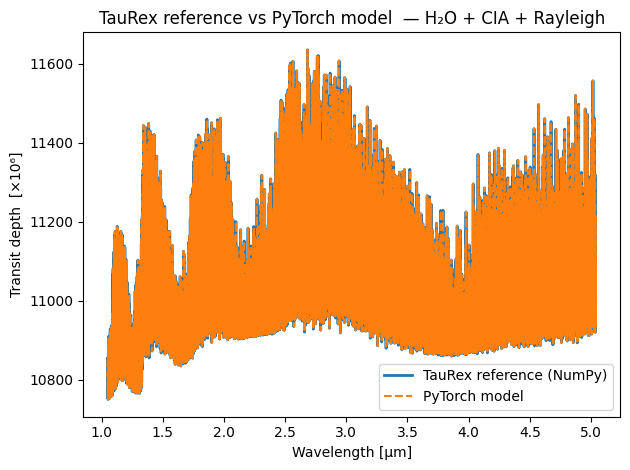

In [12]:
T_val          = torch.tensor(1500.0, dtype=torch.float64, requires_grad=True)
log10_H2O_val  = torch.tensor(-4.0,  dtype=torch.float64, requires_grad=True)

depth_torch = transmission_torch(T_val, log10_H2O_val, c=cache)

fig, ax = plt.subplots()
ax.plot(10000.0 / wngrid, spectrum * 1e6,
        label="TauRex reference (NumPy)", lw=2)
ax.plot(10000.0 / wngrid, depth_torch.detach().numpy() * 1e6,
        label="PyTorch model", lw=1.5, linestyle="--")
ax.set_xlabel("Wavelength [µm]")
ax.set_ylabel("Transit depth  [×10⁶]")
ax.set_title("TauRex reference vs PyTorch model  — H₂O + CIA + Rayleigh")
ax.legend()
plt.tight_layout()
plt.show()


### 3b. Timing: is the differentiable version competitive?

This is the key cost comparison: TauRex as reference, PyTorch forward only, and PyTorch forward plus gradient. For HMC, the last line is the relevant one.

In [13]:
import timeit

N = 50
T_b, H2O_b = torch.tensor(1500.0, dtype=torch.float64), torch.tensor(-4.0, dtype=torch.float64)

t_taurex = timeit.timeit(lambda: tm.model(wngrid), number=N) / N * 1e3

t_torch_cached = timeit.timeit(
    lambda: transmission_torch(T_b, H2O_b, c=cache), number=N
) / N * 1e3

def fwd_and_grad():
    T_g   = torch.tensor(1500.0, dtype=torch.float64, requires_grad=True)
    H2O_g = torch.tensor(-4.0,   dtype=torch.float64, requires_grad=True)
    torch.autograd.grad(transmission_torch(T_g, H2O_g, c=cache).sum(), [T_g, H2O_g])

t_torch_grad = timeit.timeit(fwd_and_grad, number=N) / N * 1e3

print(f"{'Benchmark':<45} {'ms/call':>8}   {'vs TauRex':>10}")
print("-" * 67)
print(f"{'TauRex (NumPy)':<45} {t_taurex:>8.3f}")
print(f"{'PyTorch (cached, forward)':<45} {t_torch_cached:>8.3f}   {t_torch_cached/t_taurex:>9.2f}×")
print(f"{'PyTorch (cached, fwd + grad)':<45} {t_torch_grad:>8.3f}   {t_torch_grad/t_taurex:>9.2f}×")
print(f"\nGradient overhead: {t_torch_grad-t_torch_cached:.3f} ms  "
      f"({(t_torch_grad/t_torch_cached-1)*100:.0f}% extra over fwd)")


Benchmark                                      ms/call    vs TauRex
-------------------------------------------------------------------
TauRex (NumPy)                                 130.629
PyTorch (cached, forward)                       27.159        0.21×
PyTorch (cached, fwd + grad)                    74.384        0.57×

Gradient overhead: 47.224 ms  (174% extra over fwd)


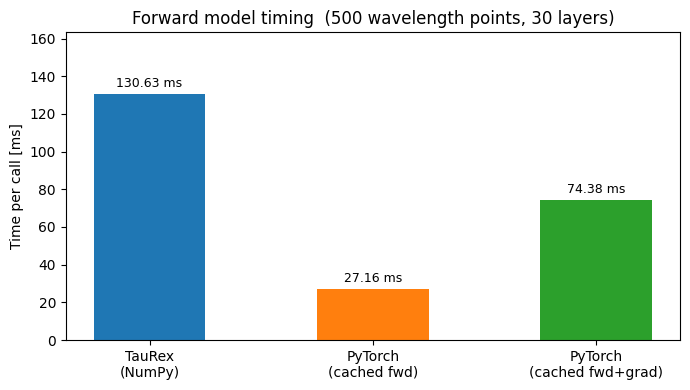

In [14]:
labels = ["TauRex\n(NumPy)", "PyTorch\n(cached fwd)", "PyTorch\n(cached fwd+grad)"]
times  = [t_taurex, t_torch_cached, t_torch_grad]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, times, color=colors, width=0.5)
ax.bar_label(bars, fmt="%.2f ms", padding=3, fontsize=9)
ax.set_ylabel("Time per call [ms]")
ax.set_title("Forward model timing  (500 wavelength points, 30 layers)")
ax.set_ylim(0, max(times) * 1.25)
plt.tight_layout()
plt.show()


### 3c. One backward pass gives the parameter gradients

This cell shows the central result: a single backward pass through the differentiable spectrum gives the derivatives with respect to temperature and log H2O abundance.

In [15]:
# Gradient of sum(depth) — a scalar — w.r.t. T and log10_H2O_mix
T2         = torch.tensor(1500.0, dtype=torch.float64, requires_grad=True)
log10_H2O2 = torch.tensor(-4.0,  dtype=torch.float64, requires_grad=True)

d = transmission_torch(T2, log10_H2O2, c=cache)
grads = torch.autograd.grad(d.sum(), [T2, log10_H2O2])

print(f"∂Σdepth/∂T             = {grads[0].item():.6e}   (exact, one backward pass)")
print(f"∂Σdepth/∂log₁₀(H₂O)   = {grads[1].item():.6e}   (exact, one backward pass)")
print()
print("Both computed simultaneously in a single backward pass.")



∂Σdepth/∂T             = 9.787691e-03   (exact, one backward pass)
∂Σdepth/∂log₁₀(H₂O)   = 2.873255e+00   (exact, one backward pass)

Both computed simultaneously in a single backward pass.


### 3d. Spectral sensitivities

The full Jacobian shows how each wavelength responds to each parameter. This is a useful diagnostic because it confirms that the model is differentiable wavelength by wavelength, not only through a scalar summary.

∂Σdepth/∂T           = 9.787691e-03   (cross-check vs autograd.grad above)
∂Σdepth/∂log₁₀(H₂O) = 2.873255e+00


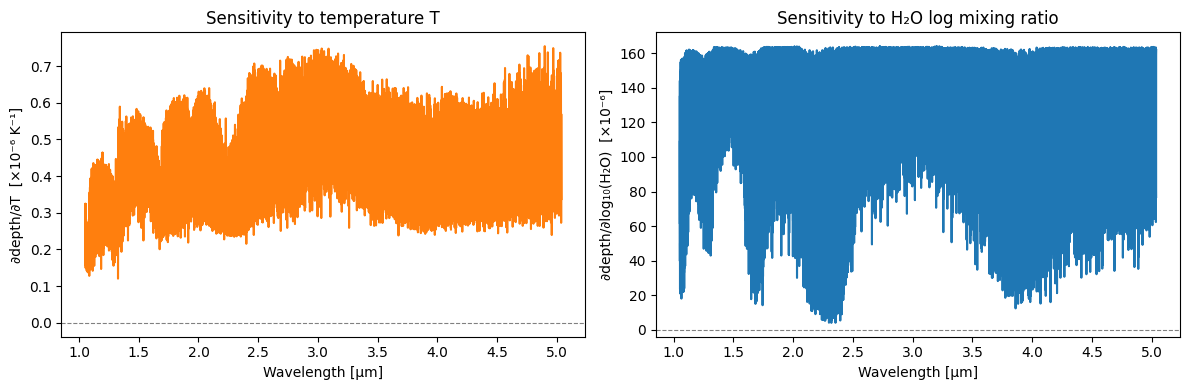

In [16]:
from torch.func import jacfwd   # forward-mode vectorised Jacobian (1 pass per scalar input vs 500 for jacrev)

T0    = torch.tensor(1500.0, dtype=torch.float64)
log10_H2O0 = torch.tensor(-4.0,  dtype=torch.float64)

# ∂depth[λ]/∂T — 500-element vector (one gradient value per wavelength)
jac_T    = jacfwd(lambda T: transmission_torch(T,    log10_H2O0, c=cache))(T0).numpy()
jac_H2O  = jacfwd(lambda h: transmission_torch(T0,   h,          c=cache))(log10_H2O0).numpy()

print(f"∂Σdepth/∂T           = {jac_T.sum():.6e}   (cross-check vs autograd.grad above)")
print(f"∂Σdepth/∂log₁₀(H₂O) = {jac_H2O.sum():.6e}")

wl = 10000.0 / wngrid

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(wl, jac_T * 1e6, color="tab:orange")
ax1.set_xlabel("Wavelength [µm]")
ax1.set_ylabel("∂depth/∂T  [×10⁻⁶ K⁻¹]")
ax1.set_title("Sensitivity to temperature T")
ax1.axhline(0, color="gray", lw=0.8, ls="--")

ax2.plot(wl, jac_H2O * 1e6, color="tab:blue")
ax2.set_xlabel("Wavelength [µm]")
ax2.set_ylabel("∂depth/∂log₁₀(H₂O)  [×10⁻⁶]")
ax2.set_title("Sensitivity to H₂O log mixing ratio")
ax2.axhline(0, color="gray", lw=0.8, ls="--")

plt.tight_layout()
plt.show()


---
## 4. Takeaways

- TauRex in its current NumPy form does not expose gradients to PyTorch autograd.
- The PyTorch rewrite reproduces the same transmission spectrum and gives exact gradients.
- The forward-plus-gradient cost stays competitive, so the differentiable formulation is practical.
- At this point the notebook has established the main result: the physics can be rewritten in PyTorch without losing the TauRex reference behaviour, and gradients are available directly.